# Task 1 — Data Exploration & Enrichment
**Project:** Ethiopia Financial Inclusion Forecasting System
**Analyst:** Dag Dagne | Selam Analytics
**Date:** 2026-07-19
**GitHub:** https://github.com/Dagi0808/ethiopia-fi-forecast

---
## Objective
1. Load and understand the unified dataset schema (observations, events, targets, impact_links)
2. Explore all record types, indicators, and temporal coverage
3. Enrich with 15 new observations, 5 new events, and 4 new impact links
4. Validate enrichment against schema rules


## 0. Setup

In [1]:
import sys, os, logging
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
plt.style.use('seaborn-v0_8-whitegrid')
FIGDIR = '../reports/figures'
os.makedirs(FIGDIR, exist_ok=True)
print("✅ Setup complete")


✅ Setup complete


## 1. Load Raw Dataset

In [2]:
from src.data_loader import load_all
data = load_all()

main   = data['main']
obs    = data['observations']
events = data['events']
targets= data['targets']
impact = data['impact_links']
ref    = data['reference']

print(f"Main dataset : {main.shape[0]} rows × {main.shape[1]} columns")
print(f"Observations : {len(obs)}")
print(f"Events       : {len(events)}")
print(f"Targets      : {len(targets)}")
print(f"Impact links : {len(impact)}")
print(f"\nColumns:")
print(main.columns.tolist())


INFO: Loaded main dataset: 43 rows, 34 columns


INFO: Loaded impact links: 14 rows


INFO: Loaded reference codes: 71 rows


INFO: load_all complete — obs=30 events=10 targets=3 impact_links=14


Main dataset : 43 rows × 34 columns
Observations : 30
Events       : 10
Targets      : 3
Impact links : 14

Columns:
['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']


## 2. Schema Understanding — Record Types and Fields

In [3]:
print("=== Record type distribution ===")
print(main['record_type'].value_counts().to_string())

print("\n=== Pillar distribution (observations + targets) ===")
print(main[main['record_type'].isin(['observation','target'])]['pillar'].value_counts(dropna=False).to_string())

print("\n=== Source types ===")
print(obs['source_type'].value_counts(dropna=False).to_string())

print("\n=== Confidence levels ===")
print(obs['confidence'].value_counts(dropna=False).to_string())

print("\n=== Key design principle: events have NULL pillar ===")
print(f"Events with pillar set: {events['pillar'].dropna().shape[0]} (should be 0)")


=== Record type distribution ===
record_type
observation    30
event          10
target          3

=== Pillar distribution (observations + targets) ===
pillar
ACCESS           16
USAGE            11
GENDER            5
AFFORDABILITY     1

=== Source types ===
source_type
operator      11
survey        10
research       4
regulator      3
calculated     2

=== Confidence levels ===
confidence
high      28
medium     2

=== Key design principle: events have NULL pillar ===
Events with pillar set: 0 (should be 0)


## 3. All Unique Indicators & Temporal Coverage

In [4]:
obs2 = obs.copy()
obs2['observation_date'] = pd.to_datetime(obs2['observation_date'], errors='coerce')
obs2['year'] = obs2['observation_date'].dt.year

ind_summary = (obs2.groupby(['pillar','indicator_code','indicator'])
               .agg(
                   records = ('record_id','count'),
                   min_year = ('year','min'),
                   max_year = ('year','max'),
                   confidence= ('confidence', lambda x: x.mode()[0] if not x.empty else 'N/A')
               )
               .reset_index()
               .sort_values(['pillar','indicator_code']))
ind_summary


,pillar,indicator_code,indicator,records,min_year,max_year,confidence
0,ACCESS,ACC_4G_COV,4G Population Coverage,2,2023,2025,high
1,ACCESS,ACC_FAYDA,Fayda Digital ID Enrollment,3,2024,2025,high
2,ACCESS,ACC_MM_ACCOUNT,Mobile Money Account Rate,2,2021,2024,high
3,ACCESS,ACC_MOBILE_PEN,Mobile Subscription Penetration,1,2025,2025,high
4,ACCESS,ACC_OWNERSHIP,Account Ownership Rate,6,2014,2024,high
5,AFFORDABILITY,AFF_DATA_INCOME,Data Affordability Index,1,2024,2024,medium
6,GENDER,GEN_GAP_ACC,Account Ownership Gender Gap,2,2021,2024,high
7,GENDER,GEN_GAP_MOBILE,Mobile Phone Gender Gap,1,2024,2024,high
8,GENDER,GEN_MM_SHARE,Female Mobile Money Account Share,1,2024,2024,high
9,USAGE,USG_ACTIVE_RATE,Mobile Money Activity Rate,1,2024,2024,high


### Temporal Coverage Heatmap

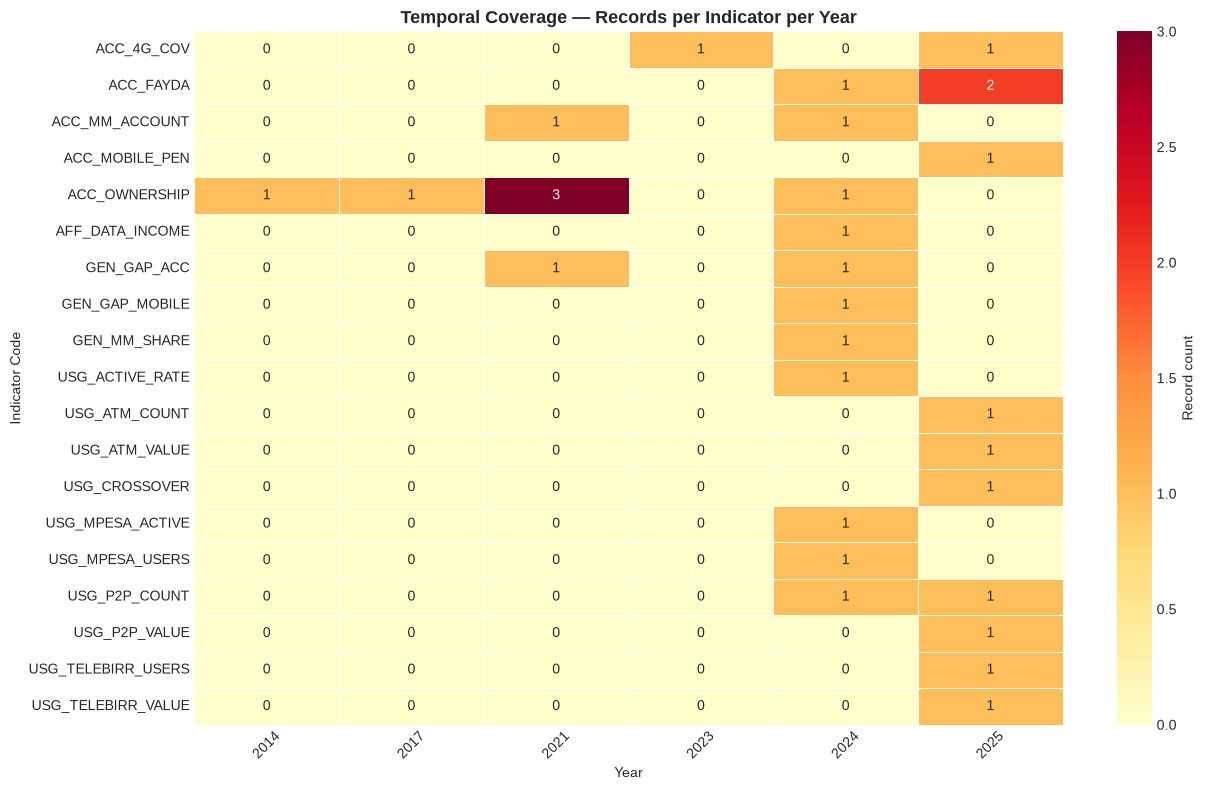

Saved: reports/figures/task1_temporal_coverage.png


In [5]:
coverage = obs2.groupby(['indicator_code','year']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(coverage, cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label':'Record count'}, annot=True, fmt='d')
ax.set_title('Temporal Coverage — Records per Indicator per Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Indicator Code')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/task1_temporal_coverage.png', dpi=150)
plt.show()
print("Saved: reports/figures/task1_temporal_coverage.png")


## 4. Events Catalog

In [6]:
events2 = events.copy()
events2['observation_date'] = pd.to_datetime(events2['observation_date'], errors='coerce')
print("=== All Events (sorted by date) ===")
events2[['record_id','category','indicator','observation_date','confidence']].sort_values('observation_date')


=== All Events (sorted by date) ===


,record_id,category,indicator,observation_date,confidence
33,EVT_0001,product_launch,Telebirr Launch,2021-05-17,high
41,EVT_0009,policy,NFIS-II Strategy Launch,2021-09-01,high
34,EVT_0002,market_entry,Safaricom Ethiopia Commercial Launch,2022-08-01,high
35,EVT_0003,product_launch,M-Pesa Ethiopia Launch,2023-08-01,high
36,EVT_0004,infrastructure,Fayda Digital ID Program Rollout,2024-01-01,high
37,EVT_0005,policy,Foreign Exchange Liberalization,2024-07-29,high
38,EVT_0006,milestone,P2P Transaction Count Surpasses ATM,2024-10-01,high
39,EVT_0007,partnership,M-Pesa EthSwitch Integration,2025-10-27,high
42,EVT_0010,pricing,Safaricom Ethiopia Price Increase,2025-12-15,high
40,EVT_0008,infrastructure,EthioPay Instant Payment System Launch,2025-12-18,high


## 5. Impact Links — Event to Indicator Relationships

In [7]:
imp_joined = (impact
    .merge(main[['record_id','indicator']], left_on='parent_id', right_on='record_id', suffixes=('','_event'))
    [['record_id','parent_id','indicator_event','pillar','related_indicator',
      'impact_direction','impact_magnitude','lag_months','evidence_basis']]
    .sort_values('parent_id'))
print(f"Total impact links: {len(imp_joined)}")
imp_joined


Total impact links: 14


,record_id,parent_id,indicator_event,pillar,related_indicator,impact_direction,impact_magnitude,lag_months,evidence_basis
0,IMP_0001,EVT_0001,Telebirr Launch,ACCESS,ACC_OWNERSHIP,increase,high,12,literature
1,IMP_0002,EVT_0001,Telebirr Launch,USAGE,USG_TELEBIRR_USERS,increase,high,3,empirical
2,IMP_0003,EVT_0001,Telebirr Launch,USAGE,USG_P2P_COUNT,increase,high,6,empirical
3,IMP_0004,EVT_0002,Safaricom Ethiopia Commercial Launch,ACCESS,ACC_4G_COV,increase,medium,12,empirical
4,IMP_0005,EVT_0002,Safaricom Ethiopia Commercial Launch,AFFORDABILITY,AFF_DATA_INCOME,decrease,medium,12,literature
5,IMP_0006,EVT_0003,M-Pesa Ethiopia Launch,USAGE,USG_MPESA_USERS,increase,high,3,empirical
6,IMP_0007,EVT_0003,M-Pesa Ethiopia Launch,ACCESS,ACC_MM_ACCOUNT,increase,medium,6,theoretical
7,IMP_0008,EVT_0004,Fayda Digital ID Program Rollout,ACCESS,ACC_OWNERSHIP,increase,medium,24,literature
8,IMP_0009,EVT_0004,Fayda Digital ID Program Rollout,GENDER,GEN_GAP_ACC,decrease,medium,24,literature
9,IMP_0010,EVT_0005,Foreign Exchange Liberalization,AFFORDABILITY,AFF_DATA_INCOME,increase,high,3,empirical


## 6. Data Quality Assessment

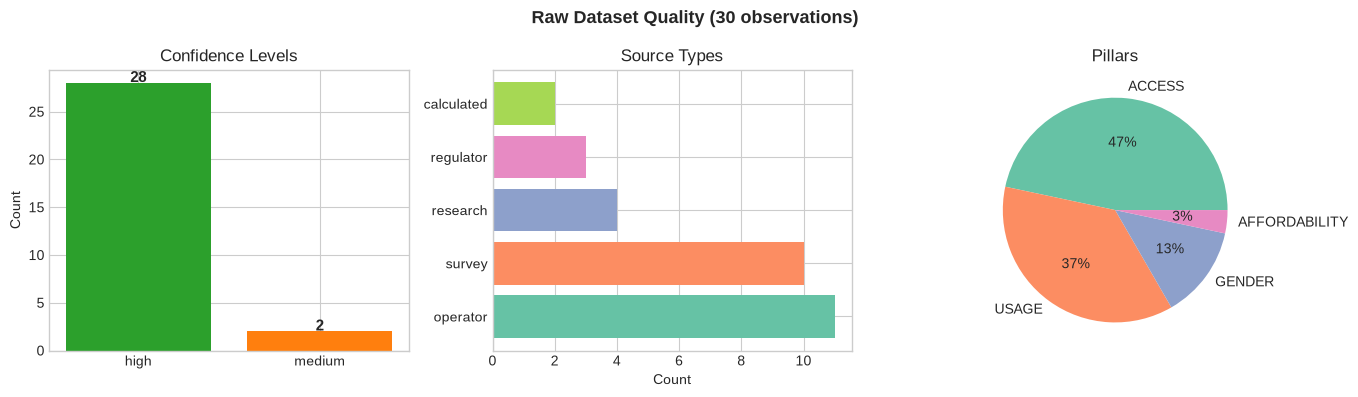


=== Missing value summary (key columns) ===
No missing values in key columns ✅


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

conf = obs['confidence'].value_counts()
axes[0].bar(conf.index, conf.values, color=['#2ca02c','#ff7f0e','#d62728'])
for i,(k,v) in enumerate(conf.items()): axes[0].text(i, v+0.1, str(v), ha='center', fontsize=11, fontweight='bold')
axes[0].set(title='Confidence Levels', ylabel='Count')

src = obs['source_type'].value_counts()
axes[1].barh(src.index, src.values, color=sns.color_palette('Set2', len(src)))
axes[1].set(title='Source Types', xlabel='Count')

pil = obs['pillar'].value_counts(dropna=False)
axes[2].pie(pil.values, labels=pil.index, autopct='%1.0f%%', colors=sns.color_palette('Set2', len(pil)))
axes[2].set_title('Pillars')

plt.suptitle('Raw Dataset Quality (30 observations)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/task1_data_quality.png', dpi=150)
plt.show()

print("\n=== Missing value summary (key columns) ===")
key_cols = ['record_id','record_type','indicator_code','value_numeric','observation_date',
            'pillar','source_name','confidence']
missing = obs[key_cols].isnull().sum()
print(missing[missing > 0].to_string() if missing.any() else "No missing values in key columns ✅")


## 7. Run Enrichment & View Summary

In [9]:
from src.enrich_data import enrich, save_processed, print_enrichment_summary

enriched_main, enriched_impact = enrich(data['main'].copy(), data['impact_links'].copy())
print_enrichment_summary(data['main'], enriched_main, enriched_impact)
save_processed(enriched_main, enriched_impact)


INFO: Enrichment validation passed — no issues found


INFO: Enrichment complete: main 43→63 (+20), impact 14→18 (+4)


INFO: Saved enriched main dataset  → /home/dag-dagne/week 11/ethiopia-fi-forecast/notebooks/../src/../data/processed/ethiopia_fi_enriched.csv


INFO: Saved enriched impact links  → /home/dag-dagne/week 11/ethiopia-fi-forecast/notebooks/../src/../data/processed/impact_links_enriched.csv



  DATA ENRICHMENT SUMMARY
  Original records  :  43
  Enriched records  :  63  (+20)
    New observations:  15
    New events      :   5
  Impact links      :  18  (original 14)

  NEW OBSERVATIONS:
  record_id    indicator_code               value  date          confidence
  --------------------------------------------------------------
  REC_0034     ACC_OWNERSHIP                 14.0  2011-12-31    high
  REC_0035     ACC_OWNERSHIP_F               16.0  2014-12-31    high
  REC_0036     ACC_OWNERSHIP_M               28.0  2014-12-31    high
  REC_0037     ACC_OWNERSHIP_F               27.0  2017-12-31    high
  REC_0038     ACC_OWNERSHIP_M               43.0  2017-12-31    high
  REC_0039     ACC_OWNERSHIP_URB             68.0  2024-11-29    high
  REC_0040     ACC_OWNERSHIP_RUR             40.0  2024-11-29    high
  REC_0041     USG_DIGITAL_PAYMENT           18.0  2021-12-31    high
  REC_0042     USG_DIGITAL_PAYMENT           35.0  2024-11-29    high
  REC_0043     ACC_MOBILE_INT

## 8. New Observations — Detailed View

In [10]:
new_obs = enriched_main[
    (enriched_main['record_type'] == 'observation') &
    (~enriched_main['record_id'].isin(data['main']['record_id']))
].copy()
new_obs['observation_date'] = pd.to_datetime(new_obs['observation_date'], errors='coerce')

new_obs[['record_id','indicator_code','value_numeric','observation_date',
         'pillar','source_name','confidence','notes']].sort_values('observation_date')


,record_id,indicator_code,value_numeric,observation_date,pillar,source_name,confidence,notes
43,REC_0034,ACC_OWNERSHIP,14.0,2011-12-31,ACCESS,Global Findex 2011,high,2011 Findex baseline — anchor point for 13-year trend. Was missing from star...
44,REC_0035,ACC_OWNERSHIP_F,16.0,2014-12-31,GENDER,Global Findex 2014 microdata,high,Enables gender gap trend from 2014. Gap 2014 = 28-16 = 12pp.
45,REC_0036,ACC_OWNERSHIP_M,28.0,2014-12-31,GENDER,Global Findex 2014 microdata,high,Paired with female 2014 to compute gender gap trend.
46,REC_0037,ACC_OWNERSHIP_F,27.0,2017-12-31,GENDER,Global Findex 2017 microdata,high,Gender gap widens to 16pp in 2017 — pre-mobile-money peak.
47,REC_0038,ACC_OWNERSHIP_M,43.0,2017-12-31,GENDER,Global Findex 2017 microdata,high,Enables full gender gap series: 2014(12pp) → 2017(16pp) → 2021(20pp) → 2024(...
50,REC_0041,USG_DIGITAL_PAYMENT,18.0,2021-12-31,USAGE,Global Findex 2021,high,Usage baseline before Telebirr ramp-up. One of the two primary forecast targ...
55,REC_0046,USG_TELEBIRR_USERS,20000000,2022-06-30,USAGE,Ethio Telecom Annual Report 2022,medium,Fills gap between launch (May 2021) and 2025 figure. Needed for growth curve...
53,REC_0044,ACC_BANK_BRANCHES,5.1,2022-12-31,ACCESS,IMF Financial Access Survey 2023,high,Very low branch density explains rural reliance on mobile money over formal ...
54,REC_0045,ACC_ATM_DENSITY,4.8,2022-12-31,ACCESS,IMF Financial Access Survey 2023,high,Contextualises the P2P/ATM crossover milestone (EVT_0006). Sub-Saharan avg i...
57,REC_0048,ELEC_ACCESS,45.0,2022-12-31,ACCESS,World Bank / ESMAP Tracking SDG7,high,Electricity is prerequisite for phone charging in rural areas (Sheet C — Ind...


## 9. New Events — Detailed View

In [11]:
new_evts = enriched_main[
    (enriched_main['record_type'] == 'event') &
    (~enriched_main['record_id'].isin(data['main']['record_id']))
].copy()
new_evts['observation_date'] = pd.to_datetime(new_evts['observation_date'], errors='coerce')

new_evts[['record_id','category','indicator','observation_date','source_name','confidence','notes']].sort_values('observation_date')


,record_id,category,indicator,observation_date,source_name,confidence,notes
58,EVT_0011,regulation,NBE Mobile and Agent Banking Directive (SBB/84/2020),2020-07-01,National Bank of Ethiopia,high,Single most important regulatory event — directly enabled Telebirr launch 10...
59,EVT_0012,regulation,NBE Payment Instrument Issuer Licensing Framework (2020),2020-10-01,National Bank of Ethiopia,high,"Underpins EthioPay, Fayda integration and future PSP market entries."
62,EVT_0015,policy,NBE National Financial Inclusion Strategy II (NFIS-II) 2021-2025,2021-09-01,National Bank of Ethiopia,high,"70% target is for adults (age 15+), not households. Sets benchmark for our f..."
60,EVT_0013,infrastructure,EthSwitch Full Interoperability Go-Live,2022-03-01,EthSwitch S.C.,high,Enables any-to-any transfers. P2P grew 25x from 2022 to 2025 — interoperabil...
61,EVT_0014,infrastructure,Fayda National ID Phase 2 — Biometric Enrolment Scale-Up,2023-06-01,National ID Program Ethiopia (NIDP),medium,Digital ID reduces KYC friction for account opening. India Aadhaar evidence:...


## 10. New Impact Links — Detailed View

In [12]:
new_links = enriched_impact[
    ~enriched_impact['record_id'].isin(impact['record_id'])
].copy()

linked = new_links.merge(enriched_main[['record_id','indicator']],
                         left_on='parent_id', right_on='record_id',
                         suffixes=('','_event'))
linked[['record_id','parent_id','indicator_event','pillar','related_indicator',
        'impact_direction','impact_magnitude','lag_months','evidence_basis','notes']]


,record_id,parent_id,indicator_event,pillar,related_indicator,impact_direction,impact_magnitude,lag_months,evidence_basis,notes
0,IMP_0015,EVT_0011,NBE Mobile and Agent Banking Directive (SBB/84/2020),ACCESS,ACC_OWNERSHIP,increase,high,10,empirical,Directive Jul 2020 → Telebirr May 2021 (10-month lag). Root regulatory cause...
1,IMP_0016,EVT_0013,EthSwitch Full Interoperability Go-Live,USAGE,USG_P2P_COUNT,increase,high,6,empirical,P2P count grew 25x (49M → 1.28B) 2024-2025. Interoperability removed cross-p...
2,IMP_0017,EVT_0013,EthSwitch Full Interoperability Go-Live,ACCESS,ACC_OWNERSHIP,increase,medium,12,literature,Interoperability reduces barriers to opening accounts — World Bank Ghana/Tan...
3,IMP_0018,EVT_0014,Fayda National ID Phase 2 — Biometric Enrolment Scale-Up,ACCESS,ACC_OWNERSHIP,increase,medium,18,literature,India Aadhaar: digital ID contributed ~35pp inclusion over 5 years. Ethiopia...


## 11. Schema Validation

In [13]:
from src.enrich_data import _validate_enrichment
issues = _validate_enrichment(enriched_main, enriched_impact)

if not issues:
    print("✅ All schema validation checks passed:")
    print("   - No duplicate record_ids")
    print("   - All events have NULL pillar (design principle respected)")
    print("   - All impact_link parent_ids reference existing events")
    print("   - All value_numeric fields are numeric")
else:
    print("⚠️  Validation issues found:")
    for issue in issues:
        print(f"   - {issue}")

print(f"\nFinal enriched dataset: {len(enriched_main)} records, {len(enriched_impact)} impact links")


✅ All schema validation checks passed:
   - No duplicate record_ids
   - All events have NULL pillar (design principle respected)
   - All impact_link parent_ids reference existing events
   - All value_numeric fields are numeric

Final enriched dataset: 63 records, 18 impact links


## 12. Enrichment Rationale Summary

| Record | Indicator | Why Added |
|--------|-----------|-----------|
| Findex 2011 (ACC_OWNERSHIP 14%) | Missing baseline | Anchors the 13-year trend; without it regression starts at 2014 |
| Male/Female ownership 2014, 2017 | Gender gap series | Enables gender trend 2014→2021→2024; 2017 was the widest gap (16pp) |
| Urban/Rural ownership 2024 | Location disaggregation | 80% of Ethiopians are rural; rural 40% vs urban 68% explains stagnation |
| USG_DIGITAL_PAYMENT 2021 & 2024 | Primary forecast target | Was described in brief but missing as structured records |
| Telebirr users 2022 (20M), 2023 (38M) | Growth curve | Fills 2021→2025 gap; needed to model M-Pesa entry impact |
| IMF FAS: branch density, ATM density | Infrastructure context | Low density (5.1/100k) explains rural mobile-money reliance |
| GSMA mobile internet 28% | Indirect correlate | r=0.91 with account ownership — leading indicator |
| ELEC_ACCESS 45% | Indirect enabler | Electricity is prerequisite for device charging in rural areas |
| NBE Directive SBB/84/2020 | Missing event | Single most important regulatory enabler for Telebirr — was absent |
| EthSwitch interoperability 2022 | Missing event | Direct cause of 25x P2P growth 2022–2025 |
| Fayda Phase 2 2023 | Missing event | Digital ID reduces KYC friction — biggest upcoming inclusion lever |
| 4 new impact links | Event-indicator relationships | NBE→ACCESS, EthSwitch→P2P/ACCESS, Fayda→ACCESS |
